In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

pd.options.display.float_format = '{:,.2f}'.format

data_month = pd.read_csv('data/monthly_deaths.csv', parse_dates=['date'])
data_year = pd.read_csv('data/annual_deaths_by_clinic.csv')

In [2]:
print(f'Shape (Yearly) : {data_year.shape}')
data_year

Shape (Yearly) : (12, 4)


,year,births,deaths,clinic
0,1841,3036,237,clinic 1
1,1842,3287,518,clinic 1
2,1843,3060,274,clinic 1
3,1844,3157,260,clinic 1
4,1845,3492,241,clinic 1
5,1846,4010,459,clinic 1
6,1841,2442,86,clinic 2
7,1842,2659,202,clinic 2
8,1843,2739,164,clinic 2
9,1844,2956,68,clinic 2


In [3]:
print(f'Shape (Monthly) : {data_month.shape}')
data_month.tail()

Shape (Monthly) : (98, 3)


,date,births,deaths
93,1848-11-01,310,9
94,1848-12-01,373,5
95,1849-01-01,403,9
96,1849-02-01,389,12
97,1849-03-01,406,20


In [4]:
print(f'NaN : {data_year.isna().values.any()}')
data_year.info()

NaN : False
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   year    12 non-null     int64 
 1   births  12 non-null     int64 
 2   deaths  12 non-null     int64 
 3   clinic  12 non-null     object
dtypes: int64(3), object(1)
memory usage: 516.0+ bytes


In [5]:
print(f'NaN : {data_month.isna().values.any()}')
data_month.info()

NaN : False
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    98 non-null     datetime64[ns]
 1   births  98 non-null     int64         
 2   deaths  98 non-null     int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 2.4 KB


In [6]:
print(f'Duplicates : {data_year.duplicated().values.any()}')
data_year.describe()

Duplicates : False


,year,births,deaths
count,12.00,12.00,12.00
mean,"1,843.50","3,152.75",223.33
std,1.78,449.08,145.38
min,"1,841.00","2,442.00",66.00
25%,"1,842.00","2,901.75",100.25
50%,"1,843.50","3,108.50",219.50
75%,"1,845.00","3,338.25",263.50
max,"1,846.00","4,010.00",518.00


In [7]:
print(f'Duplicates : {data_month.duplicated().values.any()}')
data_month[['births', 'deaths']].describe()

Duplicates : False


,births,deaths
count,98.00,98.00
mean,267.00,22.47
std,41.77,18.14
min,190.00,0.00
25%,242.50,8.00
50%,264.00,16.50
75%,292.75,36.75
max,406.00,75.00


In [8]:
maternal_deaths = data_year.deaths.sum() / data_year.births.sum() * 100
print(f'Maternal deaths during childbirth in 1840s (Vienna) : {maternal_deaths:.3}%')

Maternal deaths during childbirth in 1840s (Vienna) : 7.08%


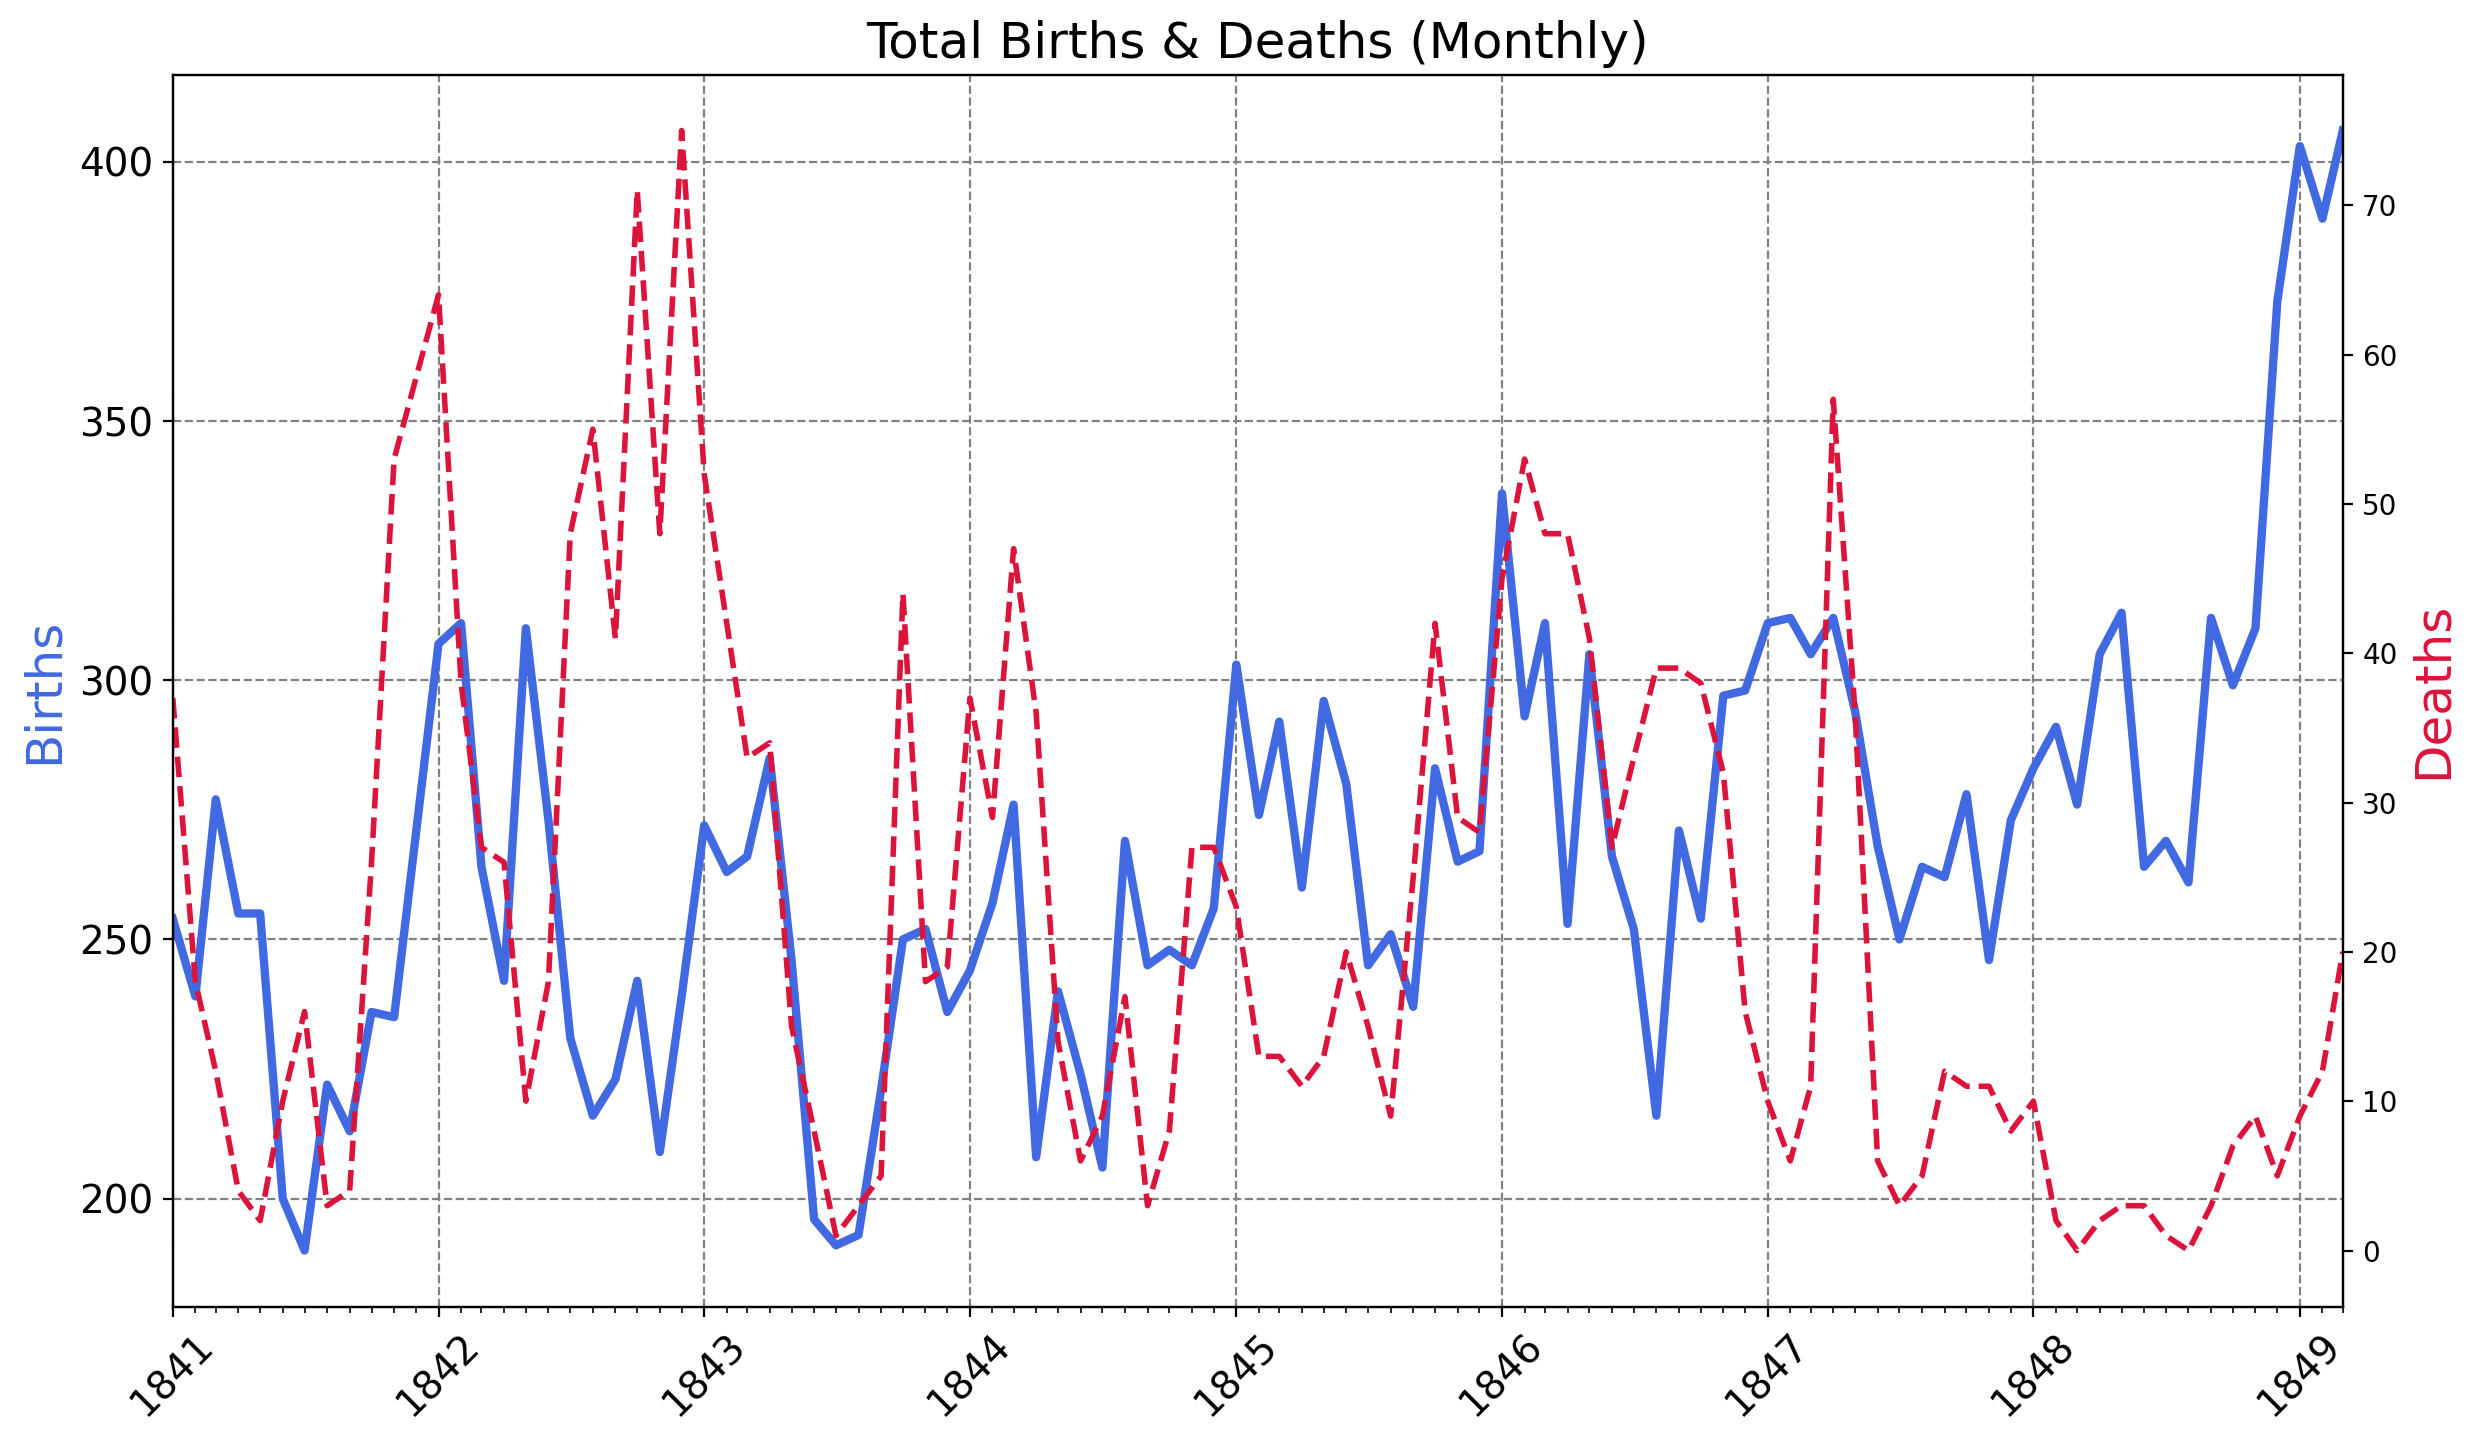

In [9]:
plt.figure(figsize=(14, 8), dpi=200)
plt.title('Total Births & Deaths (Monthly)', fontsize=18)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14, rotation=45)

ax_births = plt.gca()
ax_deaths = ax_births.twinx()

ax_births.set_ylabel('Births', color = 'royalblue', fontsize = 18)
ax_deaths.set_ylabel('Deaths', color ='crimson', fontsize = 18)

years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')

ax_births.set_xlim([data_month.date.min(), data_month.date.max()])
ax_births.xaxis.set_major_locator(years)
ax_births.xaxis.set_major_formatter(years_fmt)
ax_births.xaxis.set_minor_locator(months)

ax_births.grid(color = 'grey', linestyle = '--')

ax_births.plot(data_month.date, data_month.births, color = 'royalblue', linewidth = 3)
ax_deaths.plot(data_month.date, data_month.deaths, color = 'crimson', linewidth = 2, linestyle = '--')

plt.show()

In [10]:
line = px.line(data_year, x = 'year', y = 'births', color = 'clinic', title = 'Total Births by Clinic (Yearly)')
line.show()

In [11]:
line = px.line(data_year, x = 'year', y = 'deaths', color = 'clinic', title = 'Total Deaths by Clinic (Yearly)')
line.show()

In [12]:
data_year['deaths_pct'] = data_year.deaths / data_year.births

clinic_men = data_year[data_year.clinic == 'clinic 1']
clinic_women = data_year[data_year.clinic == 'clinic 2']

death_rate_clinic_men = clinic_men.deaths.sum() / clinic_men.births.sum() * 100
death_rate_clinic_women = clinic_women.deaths.sum() / clinic_women.births.sum() * 100

print(f"Death rate - Men's Clinic (Avg.) : {death_rate_clinic_men:.3}%")
print(f"Death rate - Women's Clinic (Avg.) : {death_rate_clinic_women:.3}%")

line = px.line(data_year, x = 'year', y = 'deaths_pct', color = 'clinic', title = 'Proportion of Deaths by Clinic (Yearly)')

line.show()

Death rate - Men's Clinic (Avg.) : 9.92%
Death rate - Women's Clinic (Avg.) : 3.88%
